### Discutere i risultati ottenuti per calcolare lo zero della funzione f (x) = e^x − x^2 nell’intervallo [−1, 1] utilizzando:
### • metodo di Newton
### • il metodo delle approssimazioni successive con g(x) = x − f(x)e^x/2
### • il metodo delle approssimazioni successive con g(x) = x − f(x)e^−x/2 mostrando la distanza tra due iterate consecutive e l’ errore commesso al variare delle iterazioni (x∗ ≈ −0.703467).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def succ_app(f, g, tolf, tolx, maxit, xTrue, x0=0):    
  i=0  
  err=np.zeros(maxit+1, dtype=np.float64)  
  err[0]=tolx+1 
  vecErrore=np.zeros(maxit+1, dtype=np.float64) 
  vecErrore[0] = np.abs(xTrue - x0) 
  x=x0 
    
    
  while (i < maxit and ((np.abs(f(x)) > tolf) or err[i] > tolx)):                                                              
    x_new= g(x) 
    err[i+1]= np.abs(x_new - x) 
    vecErrore[i+1]=  np.abs(xTrue - x_new) 
    i=i+1 
    x=x_new 
  err=err[0:i]  
  vecErrore = vecErrore[0:i] 
  return (x, i, err, vecErrore) 
 

def newton(f, df, tolf, tolx, maxit, xTrue, x0=0):
    g = lambda x: x - f(x)/df(x) 
    (x, i, err, vecErrore) = succ_app(f, g, tolf, tolx, maxit, xTrue, x0) 
    return (x, i, err, vecErrore) 


f = lambda x: np.exp(x)-x**2
df = lambda x: np.exp(x) - 2*x 
g1 = lambda x: x-f(x)*np.exp(x/2)
g2 = lambda x: x-f(x)*np.exp(-x/2)

xTrue = -0.703467
fTrue = f(xTrue) 
print('fTrue = ', fTrue) 
print('\nxTrue = ', xTrue)

fTrue =  8.035078391532835e-07

xTrue =  -0.703467


 
 Metodo approssimazioni successive g1 
 x = -0.7034674225096886 
 iter_g1= 23
 
 Metodo approssimazioni successive g2 
 x = -0.48775858993453886 
 iter_g2= 100
 
 Metodo Newton 
 x = -0.7034674224983917 
 iter_new= 6


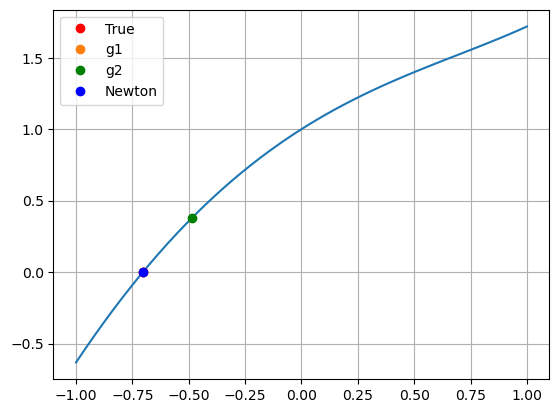

In [2]:
xplot = np.linspace(-1, 1) 
fplot = f(xplot) 

plt.plot(xplot,fplot) 
plt.plot(xTrue,fTrue, 'or', label='True') 
 
tolx= 10**(-10)  
tolf = 10**(-6) 
maxit= 100 
x0= 0 

[sol_g1, iter_g1, err_g1, vecErrore_g1]=succ_app(f, g1, tolf, tolx, maxit, xTrue, x0)
print(' \n Metodo approssimazioni successive g1 \n x =',sol_g1,'\n iter_g1=', iter_g1)

plt.plot(sol_g1,f(sol_g1), 'o', label='g1')

[sol_g2, iter_g2, err_g2, vecErrore_g2]=succ_app(f, g2, tolf, tolx, maxit, xTrue, x0)
print(' \n Metodo approssimazioni successive g2 \n x =',sol_g2,'\n iter_g2=', iter_g2)

plt.plot(sol_g2,f(sol_g2), 'og', label='g2')

[sol_newton, iter_newton, err_newton, vecErrore_newton]=newton(f, df, tolf, tolx, maxit, xTrue, x0)
print(' \n Metodo Newton \n x =',sol_newton,'\n iter_new=', iter_newton)

plt.plot(sol_newton,f(sol_newton), 'ob', label='Newton')
plt.legend()
plt.grid()
plt.show()

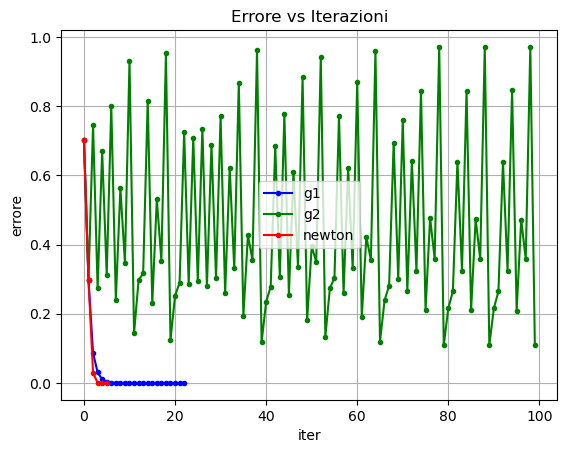

In [3]:
plt.plot(vecErrore_g1, '.-', color='blue')

plt.plot(vecErrore_g2, ".-", color='green')

plt.plot(vecErrore_newton, '.-', color='red')

plt.legend( ("g1", "g2", "newton"))
plt.xlabel('iter')
plt.ylabel('errore')
plt.title('Errore vs Iterazioni')
plt.grid()
plt.show()